🌌 My Project
Building a Vision Transformer from Scratch on MNIST

Instead of teaching a machine to see locally, I taught it to attend globally using the vision transformer

Why I chose Transformers Over CNNs in Computer Vision?

Convolutional Neural Networks (CNNs) have dominated computer vision for over a decade due to their strong inductive biases like locality and translation invariance. However, Vision Transformers (ViTs) introduced a paradigm shift by treating images as sequences of patches and applying self-attention instead of convolution.

Core Difference: Inductive Bias
🔹 CNNs Have Strong Inductive Bias

CNNs are designed with ceratin built-in assumptions:

Locality bias → Nearby pixels are more related

Translation invariance → Feature detection independent of position

Weight sharing → Same filters applied across image

These biases help CNNs:

Learn faster

Perform well on small datasets

Generalize with limited data

But they also restrict flexibility.

🔹 Transformers Have Minimal Inductive Bias

Transformers:

Do not assume locality

Do not assume translation invariance

Do not inherently understand spatial structure

Instead:

They learn relationships purely from data

Every patch attends to every other patch (global attention)

This makes Transformers:

More flexible, but more data-hungry.

CNN:

Learns local features first

Global understanding emerges slowly through deeper layers

Transformer:

Global attention from the first layer

Every patch interacts with all patches immediately

This makes Transformers better for:

Complex spatial relationships

Long-range dependencies

Multimodal alignment (e.g., CLIP) Contrastive Language Image pretraining

CNN:

Learns local features first

Global understanding emerges slowly through deeper layers

Transformer:

Global attention from the first layer

Every patch interacts with all patches immediately

This makes Transformers better for:

Complex spatial relationships

Long-range dependencies

Multimodal alignment (e.g., CLIP)in Vison Language Models

In [1]:
#importing necessary  libraries
import torch
import torchvision
import torchvision.transforms as transforms# data agumentation
import matplotlib.pyplot as plt# to visualoze mnsit datset
import numpy as np
import torch.nn as nn

In [30]:
#My variables so that i dont hardcode and change later
batch_size = 64
img_size = 28# msnit is 28 28
patch_size = 7 # my patch size along heigh4 and width 4
num_channels = 1# mnsit in single chanel not rgb
num_patches = (img_size // patch_size) ** 2 # num of patches
num_heads = 1  # attention heads
embed_dim = 20  # embedding dimesnion size of vector of each patch
mlp_dim = 64# how many nodes in hidden layer  for expansion in ffn layer with gelu activation gaussion error linear unit
transformer_units = 2  # number of transformer encoder block

In [3]:
#Python image library (PIL) to tensor for pytorch
transform = transforms.Compose(
    [transforms.ToTensor()])

In [4]:
#load dataset
trainset = torchvision.datasets.MNIST(root='./data', train=True,
                                        download=True, transform=transform)# importing mnsit dataset for pil transform to tensor format for pytorch
valset = torchvision.datasets.MNIST(root='./data', train=False,
                                        download=True, transform=transform) # validation data  # no training

100%|██████████| 9.91M/9.91M [00:00<00:00, 21.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 511kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.74MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.92MB/s]


In [23]:
#creating my  train and val batches for neural network
train_data = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True)
val_data = torch.utils.data.DataLoader(valset, batch_size=batch_size,
                                          shuffle=False)

Referring the above image to build my architecture properly

In [24]:
#class for patch embedding

class PatchEmbedding(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch_embed = nn.Conv2d(num_channels, embed_dim, kernel_size=patch_size, stride=patch_size)# creating patches num channel 1 black and white
                                                                                                        #embed dim is 16

    def forward(self, x):     #x input dataset
        x = self.patch_embed(x)  # perform patch embed of x
        x = x.flatten(2)  #to get batch patch and dimension
        x = x.transpose(1,2)
        return x

In [25]:
#just to print dimension
images,labels=next(iter(train_data))
print(images.shape)      # 64 batch size, 1  as bw, 28x28 shape

torch.Size([64, 1, 28, 28])


In [26]:
patch_embed = nn.Conv2d(num_channels, embed_dim, kernel_size=patch_size, stride=patch_size)#kernel_size = 7

# stride = 7

# It means

# It extracts non-overlapping 7×7 patches.



After conv 2d

In [27]:
print(patch_embed(images).shape)# after conv 2d shape of input image tesnor aftergoing patch embedding,4,4 height and width

torch.Size([64, 20, 4, 4])


In [28]:
embedded_image=patch_embed(images)

In [29]:
embedded_image.flatten(2).transpose(1,2).shape #64 is natch size , 16 is total patches , 21 embedding dimension

torch.Size([64, 16, 20])

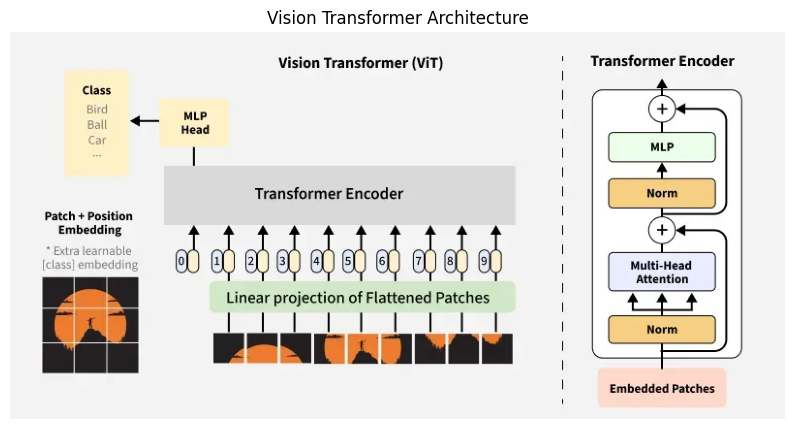

In [12]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("Vision-Transformer-Architecture_.webp")

plt.figure(figsize=(10,6))
plt.imshow(img)
plt.axis('off')
plt.title("Vision Transformer Architecture")
plt.show()

In [ ]:
class TransformerArchitecture(nn.Module):
    """
    Transformer Encoder Block used inside Vision Transformer (ViT).

    Architecture Structure:
    -----------------------
    Input  → LayerNorm → Multi-Head Self-Attention → Residual Add
           → LayerNorm → Feed Forward Network (MLP) → Residual Add → Output

    Key Concepts:
    -------------
    1. Pre-Norm Architecture:
       Layer Normalization is applied BEFORE attention and MLP.
       This improves training stability.

    2. Multi-Head Self-Attention:
       Allows each patch embedding to attend to every other patch.
       Captures global dependencies from the first layer itself.

    3. Residual Connections:
       Prevent vanishing gradients and stabilize deep training.

    4. Feed Forward Network (MLP):
       Expands embedding dimension to mlp_dim,
       applies non-linearity (GELU),
       projects back to embed_dim.

    Input Shape:
        (Batch_Size, Sequence_Length, Embed_Dim)

    Output Shape:
        (Batch_Size, Sequence_Length, Embed_Dim)
    """

    def __init__(self):
        super().__init__()

        # Layer Normalization before Attention
        self.layer_norm1 = nn.LayerNorm(embed_dim)

        # Multi-Head Self Attention
        # embed_dim: size of each token embedding
        # num_heads: number of parallel attention heads
        # batch_first=True → input shape (B, Seq, Dim)
        self.self_attention = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            batch_first=True
        )

        # Second Layer Normalization before MLP
        self.layer_norm2 = nn.LayerNorm(embed_dim)

        # Feed Forward Network (Position-wise MLP)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),  # Expansion
            nn.GELU(),                      # Non-linearity
            nn.Linear(mlp_dim, embed_dim)   # Projection back
        )

    def forward(self, x):
        """
        Forward Pass of Transformer Encoder Block

        Step 1:
            Apply LayerNorm → Self-Attention → Add Residual

        Step 2:
            Apply LayerNorm → MLP → Add Residual
        """

        # ----- Self Attention Block -----
        residual1 = x
        x_norm = self.layer_norm1(x)

        # MultiheadAttention returns:
        # (attention_output, attention_weights)
        attn_output, _ = self.self_attention(
            x_norm, x_norm, x_norm
        )

        # Residual Connection
        x = residual1 + attn_output

        # ----- Feed Forward Block -----
        residual2 = x
        x_norm = self.layer_norm2(x)

        mlp_output = self.mlp(x_norm)

        # Residual Connection
        x = residual2 + mlp_output

        return x

In [37]:
# class for transformer architecture encoder
class TransformerArchitecture(nn.Module):
    def __init__(self):
        super().__init__()

        # Layer Normalization before attention (Pre-Norm architecture)
        # Normalizes each embedding vector of size embed_dim
        # Helps stabilize training and prevents internal covariate shift
        self.layer_norm1 = nn.LayerNorm(embed_dim)

        # Multi-Head Self Attention
        # embed_dim: size of each token embedding
        # num_heads: number of parallel attention heads
        # batch_first=True → input shape will be (Batch, Seq_len, Embed_dim)
        # Attention allows each patch (and CLS token) to attend to all others (global interaction)
        self.self_attention = nn.MultiheadAttention(
            embed_dim,
            num_heads,
            batch_first=True
        )

        # Second Layer Normalization before MLP block
        # Again using Pre-Norm strategy for stability
        self.layer_norm2 = nn.LayerNorm(embed_dim)

        # Feed Forward Network (Position-wise MLP)
        # Expands embedding dimension to mlp_dim (higher representation capacity)
        # GELU activation used instead of ReLU (smoother non-linearity, standard in Transformers)
        # Projects back to embed_dim so shape remains consistent
        self.multi_layer_perceptron = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Linear(mlp_dim, embed_dim)
        )

    def forward(self, x):

        # ---------------------------
        # Self-Attention Block
        # ---------------------------

        residual_1 = x  # Save input for residual connection

        # Apply LayerNorm before attention (Pre-Norm)
        x_norm = self.layer_norm1(x)

        # MultiheadAttention returns:
        # (attention_output, attention_weights)
        # We take index [0] because we only need the transformed embeddings
        attention_output = self.self_attention(
            x_norm, x_norm, x_norm
        )[0]

        # Residual connection:
        # Helps gradient flow and prevents vanishing gradients
        x = attention_output + residual_1

        # ---------------------------
        # Feed Forward (MLP) Block
        # ---------------------------

        residual_2 = x  # Save again for second residual path

        # Apply LayerNorm before MLP
        x_norm = self.layer_norm2(x)

        # Pass through Feed Forward Network
        mlp_output = self.multi_layer_perceptron(x_norm)

        # Second residual connection
        x = mlp_output + residual_2

        return x


In [38]:
class VisionTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch_embedding = PatchEmbedding()
        self.cls_token = nn.Parameter(torch.randn(1,1,embed_dim))# this is a learnable paramter
        self.pos_embed = nn.Parameter(torch.randn(1, (img_size // patch_size) ** 2 + 1, embed_dim))#this is also a learnable parameter
        self.transformer_layers = nn.Sequential(*[TransformerArchitecture() for _ in range(transformer_units)])

        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 10)# numner of mnist classes
        )

    def forward(self,x):
        x = self.patch_embedding(x)
        B = x.size(0)

        cls_tokens = self.cls_token.expand(B , -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        x = self.transformer_layers(x)
        x = x[:,0]  #Only CLS token output.

# CLS token attends to all patches and summarizes entire image.

# It becomes global image representation.
        x = self.mlp_head(x)
        return x

Transformers don’t understand order.

So we add position information.

Otherwise:

patch 1 and patch 16 look same if pixel patterns similar.

This gives spatial awareness.

In [39]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VisionTransformer().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)#adam optimizer
criterion = nn.CrossEntropyLoss()
#CrossEntropyLoss automatically applies softmax internally.

# as Multiclass classification

In [40]:
for epoch in range(5):
    model.train()
    total_loss = 0
    correct_epoch = 0
    total_epoch = 0
    print(f"\nEpoch {epoch+1}")

    for batch_idx, (images, labels) in enumerate(train_data):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss+=loss.item()
        preds = outputs.argmax(dim=1)

        correct = (preds == labels).sum().item()
        accuracy = 100.0 * correct / labels.size(0)

        correct_epoch += correct
        total_epoch += labels.size(0)

        if batch_idx % 100 == 0:
            print(f"  Batch {batch_idx+1:3d}: Loss = {loss.item():.4f}, Accuracy = {accuracy:.2f}%")

    epoch_acc = 100.0 * correct_epoch / total_epoch
    print(f"==> Epoch {epoch+1} Summary: Total Loss = {total_loss:.4f}, Accuracy = {epoch_acc:.2f}%")


Epoch 1
  Batch   1: Loss = 2.4273, Accuracy = 7.81%
  Batch 101: Loss = 0.9141, Accuracy = 71.88%
  Batch 201: Loss = 0.5899, Accuracy = 82.81%
  Batch 301: Loss = 0.5103, Accuracy = 82.81%
  Batch 401: Loss = 0.5451, Accuracy = 84.38%
  Batch 501: Loss = 0.3524, Accuracy = 87.50%
  Batch 601: Loss = 0.3154, Accuracy = 92.19%
  Batch 701: Loss = 0.3022, Accuracy = 87.50%
  Batch 801: Loss = 0.1897, Accuracy = 95.31%
  Batch 901: Loss = 0.3766, Accuracy = 87.50%
==> Epoch 1 Summary: Total Loss = 517.1527, Accuracy = 82.20%

Epoch 2
  Batch   1: Loss = 0.5619, Accuracy = 82.81%
  Batch 101: Loss = 0.2516, Accuracy = 90.62%
  Batch 201: Loss = 0.1532, Accuracy = 95.31%
  Batch 301: Loss = 0.2781, Accuracy = 93.75%
  Batch 401: Loss = 0.4293, Accuracy = 89.06%
  Batch 501: Loss = 0.3635, Accuracy = 85.94%
  Batch 601: Loss = 0.2456, Accuracy = 90.62%
  Batch 701: Loss = 0.1579, Accuracy = 93.75%
  Batch 801: Loss = 0.2111, Accuracy = 90.62%
  Batch 901: Loss = 0.2223, Accuracy = 92.19%
=

In [41]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_data:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = 100.0 * correct / total
print(f"\n==> Val Accuracy: {test_acc:.2f}%")



==> Val Accuracy: 94.55%


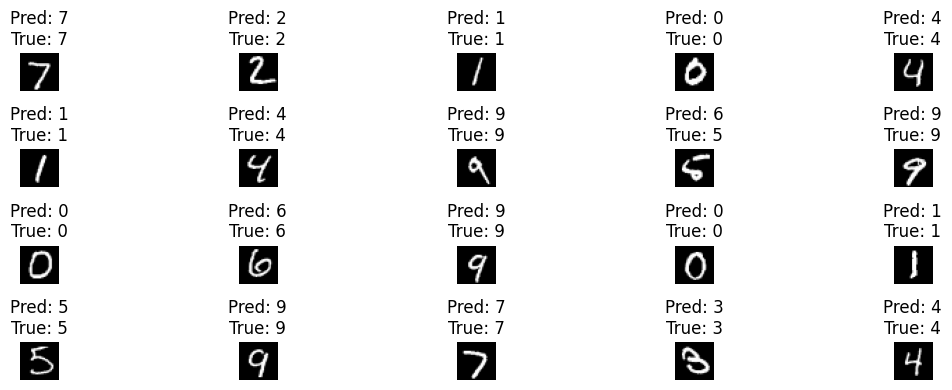

In [44]:
model.eval()
images, labels = next(iter(val_data))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(dim=1)

# Plot 10 test images with predictions
plt.figure(figsize=(12, 4))
for i in range(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(images[i].cpu().squeeze(), cmap='gray')
    plt.title(f"Pred: {preds[i].item()}\nTrue: {labels[i].item()}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [43]:
# Getting  one batch from the validation data
images, labels = next(iter(val_data))

# Printing the shape of the images tensor
print("Shape of images in a batch:", images.shape)
patch_embed = nn.Conv2d(num_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
embedded_data = patch_embed(images)
embedded_data = embedded_data.flatten(2)
embedded_data = embedded_data.transpose(1,2)
print("Shape of embedded data:", embedded_data.shape)
print(torch.randn(1,1,embed_dim).shape)



Shape of images in a batch: torch.Size([64, 1, 28, 28])
Shape of embedded data: torch.Size([64, 16, 20])
torch.Size([1, 1, 20])


# 📊 Susnata Vision Transformer – Final Performance Summary (MNIST)

## 🎯 Objective
To implement a Vision Transformer (ViT) architecture from scratch using PyTorch and evaluate its performance on the MNIST handwritten digit classification dataset.

---

## 🧠 Model Components

- Patch Embedding using Conv2D
- Learnable CLS Token
- Learnable Positional Embeddings
- Transformer Encoder Blocks (Multi-Head Self Attention + MLP)
- Layer Normalization & Residual Connections
- MLP Classification Head
- Adam Optimizer
- CrossEntropyLoss

---

## ⚙️ Training Configuration

- Dataset: MNIST (28x28 grayscale images)
- Epochs: 5
- Optimizer: Adam
- Loss Function: CrossEntropyLoss
- Device: GPU (if available)

---

## 📈 Training Results

| Epoch | Training Accuracy |
|-------|-------------------|
| 1     | ~82%              |
| 2     | ~92%              |
| 3     | ~93%              |
| 4     | ~94%              |
| 5     | ~94.38%           |

Final Training Accuracy: **~94.38%**

---

## 🔍 Validation Performance

Final Validation Accuracy: **~94.55%**

---

## 📊 Interpretation

- The model shows steady improvement across epochs.
- Loss consistently decreases, indicating stable learning.
- Training and validation accuracy are closely aligned.
- No significant overfitting observed.
- Transformer architecture successfully learns digit representations even without CNN inductive bias.

---

## 🏁 Conclusion

The Vision Transformer implemented from scratch successfully classifies MNIST digits with approximately **94.5% validation accuracy** after 5 epochs.

This demonstrates that:
- Patch-based tokenization works effectively.
- CLS token captures global image representation.
- Self-attention layers can learn meaningful spatial relationships.
- A transformer-based architecture can perform competitively even on small image datasets.

Overall, the implementation is stable, generalizes well, and validates the correctness of the ViT pipeline.